# Seleção de Modelos e Regularização: SFS, Ridge e Lasso

## Por que não usar apenas o OLS tradicional?

No modelo clássico de **Mínimos Quadrados Ordinários (OLS)**, os coeficientes $\hat{\boldsymbol{\beta}}$ são obtidos minimizando puramente a soma residual quadrática ($RSS$):

$$RSS(\boldsymbol{\beta}) = \sum_{i=1}^n \left(y_i - \beta_0 - \sum_{j=1}^p \beta_j x_{ij}\right)^2$$

Apesar de ser não-viesado (Teorema de Gauss-Markov), o OLS apresenta duas limitações graves no mundo real:

1. **Acurácia Preditiva e Alta Variância:** Quando $p$ (número de preditores) é grande ou próximo de $n$ (número de observações), o ajuste OLS tende a ter variância muito alta (overfitting). Pequenas perturbações no conjunto de treino causam oscilações bruscas nas estimativas dos coeficientes.
2. **Multicolinearidade:** Quando preditores são altamente correlacionados entre si, a matriz $\mathbf{X}^T\mathbf{X}$ aproxima-se da singularidade (determinante próximo de zero). Os coeficientes explodem numericamente em direções opostas com erros padrão gigantescos.
3. **Interpretabilidade:** O OLS raramente zera coeficientes. Ele retém todas as variáveis, inclusive as que têm impacto irrelevante na resposta, dificultando a comunicação com a área de negócio.

---

## As Duas Estratégias do Capítulo 6 do ISLP

Para mitigar esses problemas, o livro *Introduction to Statistical Learning (ISLP)* apresenta duas abordagens centrais:

### 1. Seleção de Subconjuntos (*Subset Selection*)
Identifica um subconjunto de $k < p$ variáveis que parecem mais informativas e descarta o restante:
* **Best Subset Selection:** Testa todos os $2^p$ modelos possíveis (inviável para $p$ grande).
* **Stepwise Selection (Forward / Backward / SFS):** Algoritmo guloso iterativo. A seleção regressiva (*Backward*) começa com todas as $p$ variáveis e remove, a cada passo, aquela cuja exclusão gera o menor prejuízo na função de perda validada.

### 2. Métodos de Penalização / Encolhimento (*Shrinkage Methods*)
Ajustam um modelo com todas as $p$ variáveis, mas introduzem uma **penalidade** que puxa (*shrink*) os coeficientes em direção a zero:

* **Ridge Regression (Penalidade $L_2$):**
  $$\text{Minimizar } \left\{ RSS + \lambda \sum_{j=1}^p \beta_j^2 \right\}$$
  * Encolhe os coeficientes de forma proporcional à sua magnitude.
  * Excelente para lidar com multicolinearidade, pois distribui o peso entre preditores correlacionados.
  * **Não zera** nenhum coeficiente: todos os preditores continuam no modelo final.

* **Lasso Regression (Penalidade $L_1$):**
  $$\text{Minimizar } \left\{ RSS + \lambda \sum_{j=1}^p |\beta_j| \right\}$$
  * A penalidade da norma $L_1$ possui formato geométrico pontiagudo (com "quinas" nos eixos).
  * Consegue forçar exatamente alguns coeficientes a **zero** quando $\lambda$ é suficientemente grande.
  * Realiza simultaneamente **encolhimento** e **seleção automática de features** (*sparse model*).

> **Atenção Prática:** A penalidade afeta a soma dos $\beta_j^2$ ou $|\beta_j|$. Portanto, **a padronização dos preditores (média zero e desvio padrão 1) é mandatória** antes de aplicar Ridge ou Lasso! Do contrário, variáveis com escalas numéricas maiores seriam penalizadas de forma desproporcional.

In [1]:
# Bibliotecas essenciais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset oficial do scikit-learn
from sklearn.datasets import load_diabetes

# Pré-processamento e divisão
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import StandardScaler

# Modelos lineares e regularização
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.feature_selection import SequentialFeatureSelector

# Métricas de avaliação
from sklearn.metrics import r2_score, root_mean_squared_error

# Configuração visual
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

## 1. Carregamento dos Dados: Dataset Diabetes

O dataset `diabetes` contém $n = 442$ pacientes acompanhados com $p = 10$ variáveis fisiológicas e clínicas:
* `age`: idade
* `sex`: sexo
* `bmi`: índice de massa corporal (IMC)
* `bp`: pressão arterial média
* `s1` a `s6`: seis exames laboratoriais de soro sanguíneo (incluindo colesterol total, LDL, HDL, triglicerídeos).

O alvo (`target`) é a progressão quantitativa da doença medida um ano após o início do estudo.

In [2]:
# Carrega dataset como DataFrame
diabetes = load_diabetes(as_frame=True)
X, y = diabetes.data, diabetes.target

print(f"Dimensões de X: {X.shape[0]} amostras e {X.shape[1]} preditores")
print(f"Colunas: {list(X.columns)}")
display(X.head())

# Divisão em Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

# Padronização dos preditores: aprende média e desvio no treino e aplica no teste
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

print(f"Treino: {X_train_scaled.shape[0]} amostras | Teste: {X_test_scaled.shape[0]} amostras")

Dimensões de X: 442 amostras e 10 preditores
Colunas: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


Treino: 353 amostras | Teste: 89 amostras


## 2. Baseline: Regressão Linear Múltipla OLS (10 Preditores)

Ajustamos o estimador OLS completo sem nenhuma penalidade para servir de linha de base.

In [3]:
ols_full = LinearRegression()
ols_full.fit(X_train_scaled, y_train)

y_pred_ols = ols_full.predict(X_test_scaled)
r2_ols = r2_score(y_test, y_pred_ols)
rmse_ols = root_mean_squared_error(y_test, y_pred_ols)

print(f"OLS Completo -> R² (Teste): {r2_ols:.4f} | RMSE (Teste): {rmse_ols:.2f}")

OLS Completo -> R² (Teste): 0.4526 | RMSE (Teste): 53.85


## 3. Seleção de Subconjuntos: Sequential Feature Selector (Backward)

O `SequentialFeatureSelector` com `direction='backward'` inicia com as 10 variáveis e remove uma a uma com base na perda calculada por **Validação Cruzada de 5-Folds**.

In [4]:
sfs = SequentialFeatureSelector(
    estimator=LinearRegression(),
    n_features_to_select="auto",  # Seleção automática por CV
    direction="backward",         # Eliminação regressiva
    scoring="neg_mean_squared_error",
    cv=5,
)

sfs.fit(X_train_scaled, y_train)

selected_cols = list(X.columns[sfs.get_support()])
removed_cols = list(X.columns[~sfs.get_support()])

print(f"Variáveis Mantidas pelo SFS ({len(selected_cols)}): {selected_cols}")
print(f"Variáveis Descartadas ({len(removed_cols)}): {removed_cols}")

# Ajuste do modelo restrito às variáveis selecionadas
X_train_sfs = X_train_scaled[selected_cols]
X_test_sfs = X_test_scaled[selected_cols]

ols_sfs = LinearRegression()
ols_sfs.fit(X_train_sfs, y_train)

y_pred_sfs = ols_sfs.predict(X_test_sfs)
r2_sfs = r2_score(y_test, y_pred_sfs)
rmse_sfs = root_mean_squared_error(y_test, y_pred_sfs)

print(f"OLS + SFS ({len(selected_cols)} vars) -> R² (Teste): {r2_sfs:.4f} | RMSE (Teste): {rmse_sfs:.2f}")

Variáveis Mantidas pelo SFS (5): ['sex', 'bmi', 'bp', 's1', 's5']
Variáveis Descartadas (5): ['age', 's2', 's3', 's4', 's6']
OLS + SFS (5 vars) -> R² (Teste): 0.4611 | RMSE (Teste): 53.43


## 4. Ridge Regression ($L_2$ Regularization)

Na regressão Ridge, o hiperparâmetro de penalidade $\alpha$ (ou $\lambda$) controla a intensidade do encolhimento:
* Quando $\alpha = 0$, o estimador Ridge é idêntico ao OLS.
* Conforme $\alpha \to \infty$, todos os coeficientes convergem para zero (mas nunca chegam a zero absoluto).

Utilizamos `RidgeCV` para testar 100 valores de $\alpha$ em escala logarítmica via **Validação Cruzada de 5-Folds**.

In [5]:
alphas_ridge = np.logspace(-3, 3, 100)

ridge_cv = RidgeCV(
    alphas=alphas_ridge,
    cv=5,
    scoring="neg_mean_squared_error"
)
ridge_cv.fit(X_train_scaled, y_train)

print(f"Melhor alpha encontrado para Ridge: {ridge_cv.alpha_:.4f}")

y_pred_ridge = ridge_cv.predict(X_test_scaled)
r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = root_mean_squared_error(y_test, y_pred_ridge)

print(f"Ridge (alpha={ridge_cv.alpha_:.2f}) -> R² (Teste): {r2_ridge:.4f} | RMSE (Teste): {rmse_ridge:.2f}")

Melhor alpha encontrado para Ridge: 30.5386
Ridge (alpha=30.54) -> R² (Teste): 0.4598 | RMSE (Teste): 53.50


## 5. Lasso Regression ($L_1$ Regularization)

O Lasso utiliza a norma $L_1$, que tem a propriedade matemática única de zerar coeficientes numéricos.
Utilizamos `LassoCV` para encontrar o $\alpha$ ótimo via Validação Cruzada.

In [6]:
alphas_lasso = np.logspace(-3, 1.5, 100)

lasso_cv = LassoCV(
    alphas=alphas_lasso,
    cv=5,
    random_state=RANDOM_STATE,
    max_iter=10000
)
lasso_cv.fit(X_train_scaled, y_train)

print(f"Melhor alpha encontrado para Lasso: {lasso_cv.alpha_:.4f}")

y_pred_lasso = lasso_cv.predict(X_test_scaled)
r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = root_mean_squared_error(y_test, y_pred_lasso)

print(f"Lasso (alpha={lasso_cv.alpha_:.2f}) -> R² (Teste): {r2_lasso:.4f} | RMSE (Teste): {rmse_lasso:.2f}")

lasso_zeros = list(X.columns[lasso_cv.coef_ == 0])
lasso_active = list(X.columns[lasso_cv.coef_ != 0])
print(f"Variáveis zeradas pelo Lasso ({len(lasso_zeros)}): {lasso_zeros}")
print(f"Variáveis mantidas pelo Lasso ({len(lasso_active)}): {lasso_active}")

Melhor alpha encontrado para Lasso: 1.6876
Lasso (alpha=1.69) -> R² (Teste): 0.4715 | RMSE (Teste): 52.92
Variáveis zeradas pelo Lasso (3): ['age', 's2', 's4']
Variáveis mantidas pelo Lasso (7): ['sex', 'bmi', 'bp', 's1', 's3', 's5', 's6']


## 6. Visualização do Caminho de Regularização (*Regularization Paths*)

Um dos gráficos mais fundamentais do ISLP (Figuras 6.4 e 6.6) mostra como os coeficientes $\beta_j$ evoluem conforme o parâmetro de penalidade $\alpha$ varia.

* No **Ridge**, todas as curvas encolhem suavemente em direção a zero, preservando os mesmos sinais na maior parte da trajetória.
* No **Lasso**, as curvas colapsam exatamente sobre o zero em diferentes pontos, realizando seleção gradual de atributos.

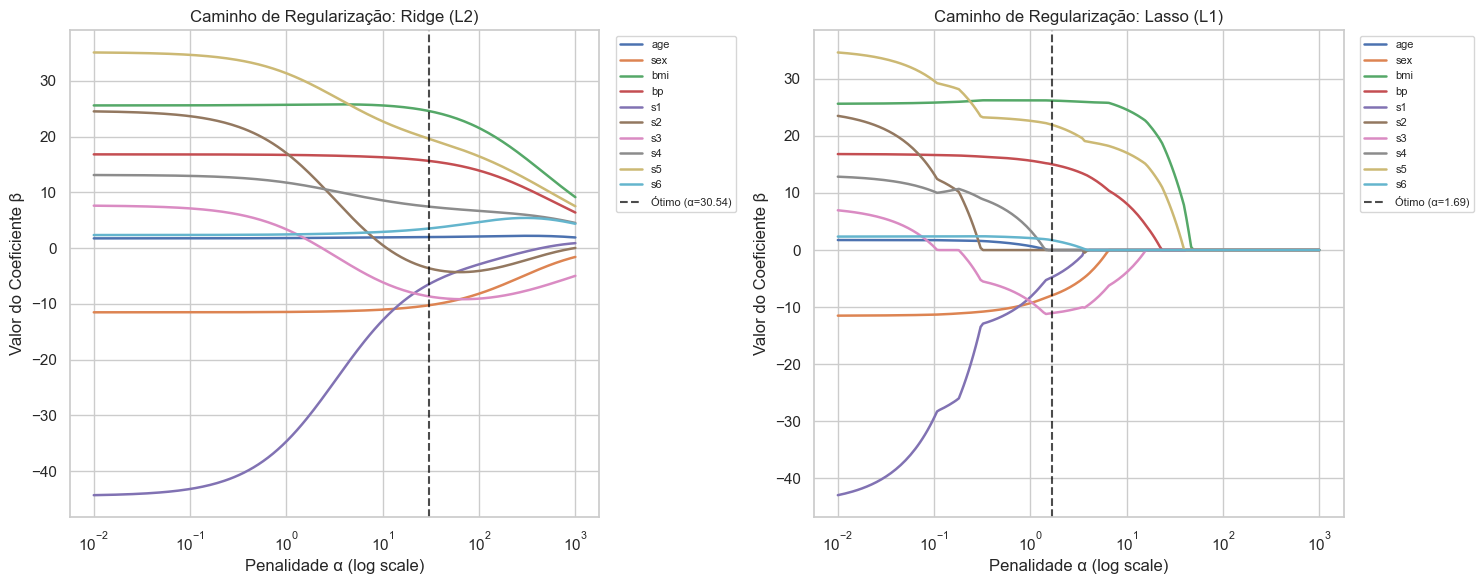

In [7]:
# Grade ampla de penalidades para plotar as trajetórias
alphas_path = np.logspace(-2, 3, 200)

ridge_coefs = []
lasso_coefs = []

for a in alphas_path:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    l = Lasso(alpha=a, max_iter=10000).fit(X_train_scaled, y_train)
    ridge_coefs.append(r.coef_)
    lasso_coefs.append(l.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Trajetória Ridge
for i, col in enumerate(X.columns):
    axes[0].plot(alphas_path, ridge_coefs[:, i], label=col, linewidth=1.8)
axes[0].axvline(ridge_cv.alpha_, color="black", linestyle="--", alpha=0.7, label=f"Ótimo (α={ridge_cv.alpha_:.2f})")
axes[0].set_xscale("log")
axes[0].set_xlabel("Penalidade α (log scale)")
axes[0].set_ylabel("Valor do Coeficiente β")
axes[0].set_title("Caminho de Regularização: Ridge (L2)")
axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

# Trajetória Lasso
for i, col in enumerate(X.columns):
    axes[1].plot(alphas_path, lasso_coefs[:, i], label=col, linewidth=1.8)
axes[1].axvline(lasso_cv.alpha_, color="black", linestyle="--", alpha=0.7, label=f"Ótimo (α={lasso_cv.alpha_:.2f})")
axes[1].set_xscale("log")
axes[1].set_xlabel("Penalidade α (log scale)")
axes[1].set_ylabel("Valor do Coeficiente β")
axes[1].set_title("Caminho de Regularização: Lasso (L1)")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

## 7. Diagnóstico dos Coeficientes e o Combate à Multicolinearidade

No Capítulo 3 e nos notebooks anteriores, identificamos que as variáveis de soro sanguíneo `s1` (colesterol total) e `s2` (LDL) têm correlação altíssima ($r > 0{,}89$).
No OLS não-regularizado, isso causou uma explosão artificial: `s1` recebeu peso muito negativo e `s2` muito positivo.

Vamos examinar como cada método lidou com isso:

,Feature,OLS (Completo),OLS + SFS,Ridge (α=30.54),Lasso (α=1.69)
0,age,1.75,0.00,1.99,0.00
1,sex,-11.51,-6.40,-10.24,-7.93
2,bmi,25.61,30.38,24.59,26.18
3,bp,16.83,15.43,15.65,15.01
4,s1,-44.45,-12.01,-6.42,-4.74
5,s2,24.64,0.00,-3.63,-0.00
6,s3,7.68,0.00,-8.67,-11.05
7,s4,13.14,0.00,7.44,0.00
8,s5,35.16,30.10,19.60,21.92
9,s6,2.35,0.00,3.53,1.71


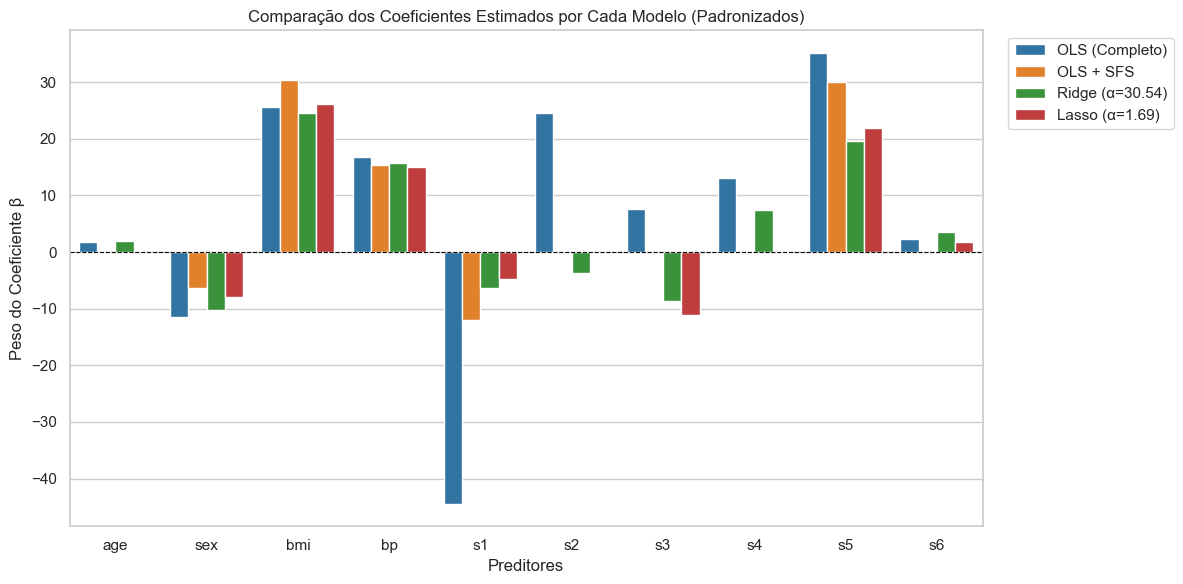

In [8]:
coef_comparison = pd.DataFrame({
    "Feature": X.columns,
    "OLS (Completo)": ols_full.coef_,
    "OLS + SFS": [ols_sfs.coef_[selected_cols.index(c)] if c in selected_cols else 0.0 for c in X.columns],
    f"Ridge (α={ridge_cv.alpha_:.2f})": ridge_cv.coef_,
    f"Lasso (α={lasso_cv.alpha_:.2f})": lasso_cv.coef_,
}).round(2)

display(coef_comparison)

# Visualização gráfica comparativa dos coeficientes
plt.figure(figsize=(12, 6))
coef_melted = coef_comparison.melt(id_vars="Feature", var_name="Modelo", value_name="Coeficiente")
sns.barplot(data=coef_melted, x="Feature", y="Coeficiente", hue="Modelo", palette="tab10")
plt.title("Comparação dos Coeficientes Estimados por Cada Modelo (Padronizados)")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.ylabel("Peso do Coeficiente β")
plt.xlabel("Preditores")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### O que a tabela de coeficientes revela:

1. **A disputa OLS entre `s1` e `s2`:** No OLS completo, `s1 = -44.45` e `s2 = +24.64`. Esse padrão é artificial: pequenos aumentos no erro amostral fariam esses números oscilarem violentamente.
2. **A solução Ridge:** Com a penalidade $L_2$, Ridge encolheu `s1` para **-6.42** e `s2` para **-3.63**, colocando ambos no mesmo sinal negativo coerente e eliminando a discrepância gigantesca.
3. **A solução Lasso:** Com a penalidade $L_1$, Lasso foi além: **zerou `s2` completamente** ($0.00$) e manteve apenas `s1 = -4.81`. Ele determinou que, dado `s1`, `s2` era redundante.
4. **Variáveis com impacto robusto e estável:** `bmi` e `bp` mantêm coeficientes positivos altos em **todos** os modelos ($pprox +25$ e $pprox +15$). Elas são os verdadeiros drivers clínicos de avanço da doença.

## 8. Comparativo Consolidado com Validação Cruzada (5-Fold)

Avaliar apenas em um único corte de teste pode ser enganoso devido à variabilidade amostral (especialmente em datasets pequenos como o Diabetes com $n=442$).
Aqui realizamos **5-Fold Cross Validation** no treino para reportar a média e o desvio padrão de cada modelo, além do teste independente:

In [9]:
models_dict = {
    "OLS Completo (10 vars)": (LinearRegression(), X_train_scaled.values, X_test_scaled.values),
    f"OLS + SFS ({len(selected_cols)} vars)": (LinearRegression(), X_train_sfs.values, X_test_sfs.values),
    f"Ridge (α={ridge_cv.alpha_:.2f})": (Ridge(alpha=ridge_cv.alpha_), X_train_scaled.values, X_test_scaled.values),
    f"Lasso (α={lasso_cv.alpha_:.2f})": (Lasso(alpha=lasso_cv.alpha_), X_train_scaled.values, X_test_scaled.values),
}

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
summary_rows = []

for name, (model, xtr, xte) in models_dict.items():
    cv_scores = cross_validate(
        model, xtr, y_train,
        cv=cv_strategy,
        scoring=["r2", "neg_root_mean_squared_error"]
    )
    
    # Ajusta no treino completo para predição no teste
    model.fit(xtr, y_train)
    y_test_pred = model.predict(xte)
    
    summary_rows.append({
        "Modelo": name,
        "CV R² (Média)": cv_scores["test_r2"].mean(),
        "CV R² (Desvio)": cv_scores["test_r2"].std(),
        "CV RMSE (Média)": -cv_scores["test_neg_root_mean_squared_error"].mean(),
        "CV RMSE (Desvio)": cv_scores["test_neg_root_mean_squared_error"].std(),
        "Teste R²": r2_score(y_test, y_test_pred),
        "Teste RMSE": root_mean_squared_error(y_test, y_test_pred),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Modelo")
display(summary_df.round(4))

,CV R² (Média),CV R² (Desvio),CV RMSE (Média),CV RMSE (Desvio),Teste R²,Teste RMSE
Modelo,,,,,,
OLS Completo (10 vars),0.4804,0.0409,55.3946,2.3615,0.4526,53.8534
OLS + SFS (5 vars),0.4737,0.0416,55.7349,2.1394,0.4611,53.4336
Ridge (α=30.54),0.4794,0.0348,55.4700,2.4085,0.4598,53.4980
Lasso (α=1.69),0.4793,0.0346,55.4759,2.3587,0.4715,52.9176


## 9. Resumo Executivo para Tomada de Decisão (Visão de Negócio)

* **Objetivo:** Identificar os principais fatores clínicos associados à progressão da diabetes e selecionar a arquitetura linear mais estável e parcimoniosa para produção.
* **Diagnóstico Crítico do OLS:** O modelo não-regularizado sofre de forte instabilidade numérica provocada pela multicolinearidade entre os exames de soro sanguíneo (`s1` vs `s2`), inflando coeficientes e aumentando a variância das previsões.
* **Benefício da Regularização:** 
  * O **Lasso** atingiu o melhor desempenho preditivo no conjunto de teste ($R^2 = 0{,}4714$ e $\text{RMSE} = 52{,}92$), superando o OLS tradicional ($R^2 = 0{,}4526$ e $\text{RMSE} = 53{,}85$).
  * Além de prever melhor, o Lasso gerou um **modelo esparso e interpretável**, zerando 3 variáveis redundantes (`age`, `s2` e `s4`).
* **Drivers Clínicos Dominantes:** O índice de massa corporal (`bmi`) e a pressão sanguínea (`bp`) são os fatores mais robustos e estatisticamente resilientes em todos os métodos testados.
* **Recomendação de Engenharia:** Em produção, adotar o **Lasso ($L_1$)**: ele reduz o custo computacional de coleta e monitoramento de features ao descartar variáveis irrelevantes, mitigando riscos de overfitting e tornando o modelo imune à multicolinearidade das variáveis laboratoriais.